## Importing Libraries

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Read the data-set:

In [4]:
%%time
df = pd.read_csv('CICIDS2018_Balanced_100k.csv')

df["Label"].value_counts()

CPU times: total: 8.77 s
Wall time: 8.98 s


Label
Bot                         100000
DDoS attacks-LOIC-HTTP      100000
Infilteration               100000
Benign                      100000
DDOS attack-HOIC            100000
DoS attacks-Hulk            100000
SSH-Bruteforce               94048
DoS attacks-GoldenEye        41406
DoS attacks-Slowloris         9908
DDOS attack-LOIC-UDP          1730
Brute Force -Web               555
Brute Force -XSS               228
SQL Injection                   84
DoS attacks-SlowHTTPTest        55
FTP-BruteForce                  54
Name: count, dtype: int64

In [5]:
df.head(3)

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,5004208,5,3,646,364,646,0,129.2,...,20,0,0,0,0,0.00,0.000000e+00,0,0,Brute Force -Web
1,500,17,89479715,6,0,3000,0,500,500,500.0,...,8,4000276,0,4000276,4000276,21369859.75,1.528101e+07,41990274,7200470,Brute Force -Web
2,80,6,11,2,0,0,0,0,0,0.0,...,20,0,0,0,0,0.00,0.000000e+00,0,0,Brute Force -Web


### Handle infinity values in the dataset

In [7]:
%%time

# Replace Infinity and -Infinity with NaN globally
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill all NaNs (including the ones we just created) with 0
df.fillna(0, inplace=True)

print("Infinity and NaN values cleaned.")

Infinity and NaN values cleaned.
CPU times: total: 734 ms
Wall time: 739 ms


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748068 entries, 0 to 748067
Data columns (total 79 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           748068 non-null  int64  
 1   Protocol           748068 non-null  int64  
 2   Flow Duration      748068 non-null  int64  
 3   Tot Fwd Pkts       748068 non-null  int64  
 4   Tot Bwd Pkts       748068 non-null  int64  
 5   TotLen Fwd Pkts    748068 non-null  int64  
 6   TotLen Bwd Pkts    748068 non-null  int64  
 7   Fwd Pkt Len Max    748068 non-null  int64  
 8   Fwd Pkt Len Min    748068 non-null  int64  
 9   Fwd Pkt Len Mean   748068 non-null  float64
 10  Fwd Pkt Len Std    748068 non-null  float64
 11  Bwd Pkt Len Max    748068 non-null  int64  
 12  Bwd Pkt Len Min    748068 non-null  int64  
 13  Bwd Pkt Len Mean   748068 non-null  float64
 14  Bwd Pkt Len Std    748068 non-null  float64
 15  Flow Byts/s        748068 non-null  float64
 16  Fl

### Drop the features that are constant at 0

In [10]:
constant = [
    "Fwd Byts/b Avg", "Fwd Pkts/b Avg", "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg", "Bwd Pkts/b Avg", "Bwd Blk Rate Avg"
]

for i in constant :
    print(f'value counts for {i}')
    print(df[i].value_counts())
    print('-' *30)

value counts for Fwd Byts/b Avg
Fwd Byts/b Avg
0    748068
Name: count, dtype: int64
------------------------------
value counts for Fwd Pkts/b Avg
Fwd Pkts/b Avg
0    748068
Name: count, dtype: int64
------------------------------
value counts for Fwd Blk Rate Avg
Fwd Blk Rate Avg
0    748068
Name: count, dtype: int64
------------------------------
value counts for Bwd Byts/b Avg
Bwd Byts/b Avg
0    748068
Name: count, dtype: int64
------------------------------
value counts for Bwd Pkts/b Avg
Bwd Pkts/b Avg
0    748068
Name: count, dtype: int64
------------------------------
value counts for Bwd Blk Rate Avg
Bwd Blk Rate Avg
0    748068
Name: count, dtype: int64
------------------------------


In [11]:
%%time
# Dropping constant features: these columns contain the same value ( 0) 
# for every row and provide no predictive power.
constant_cols = [
    "Fwd Byts/b Avg", "Fwd Pkts/b Avg", "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg", "Bwd Pkts/b Avg", "Bwd Blk Rate Avg"
]
df = df.drop(columns=constant_cols, axis=1)

CPU times: total: 188 ms
Wall time: 178 ms


### The bellow columns are the same :
* `Subflow Fwd Pkts` is identical to `Tot Fwd Pkts`
* `Subflow Fwd Byts` is identical to `TotLen Fwd Pkts`
* `Subflow Bwd Pkts` is identical to `Tot Bwd Pkts`
* `Subflow Bwd Byts` is identical to `TotLen Bwd Pkts`

In [19]:
%%time
# Dropping Subflow features: in this dataset, they are redundant 
# duplicates of the "Total" features already present.
subflow_cols = [
    "Subflow Fwd Pkts", "Subflow Fwd Byts", 
    "Subflow Bwd Pkts", "Subflow Bwd Byts"
]
df = df.drop(columns=subflow_cols, axis=1)

CPU times: total: 234 ms
Wall time: 197 ms


## Doing a correlation test to reduce the number of features and keep only the top important ones

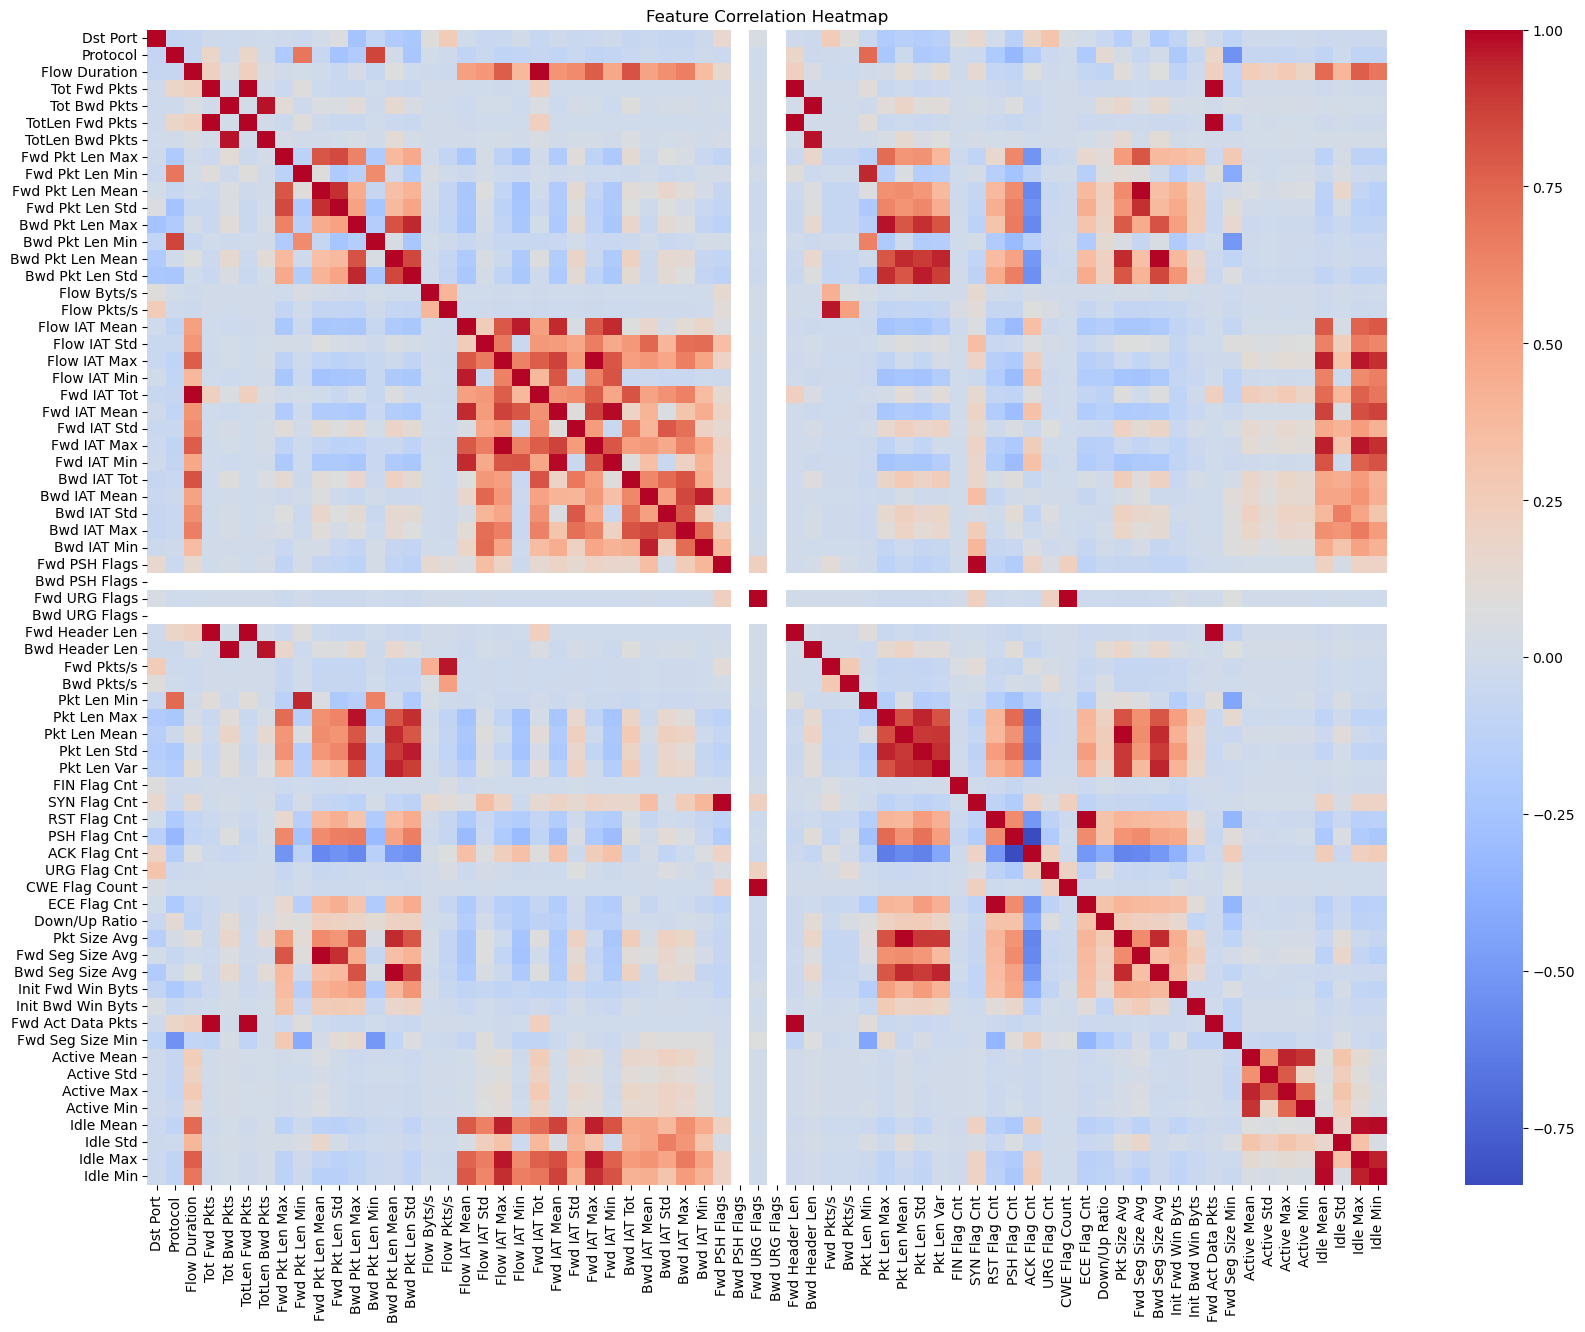

CPU times: total: 17.8 s
Wall time: 17.9 s


In [22]:
%%time
# Select only numeric features
numeric_df = df.select_dtypes(include='number')

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
%%time
# Finding pairs with correlation = 1 , so we can drop one of them.
pairs = []
columns = corr_matrix.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if abs(corr_matrix.iloc[i, j]) == 1:
            pairs.append((columns[i], columns[j], corr_matrix.iloc[i, j]))

# Sort by highest correlation
pairs.sort(key=lambda x: x[2], reverse=True)
for p in pairs:
    print(f"{p[0]} <-> {p[1]}: {p[2]:.4f}")

Fwd Pkt Len Mean <-> Fwd Seg Size Avg: 1.0000
Fwd PSH Flags <-> SYN Flag Cnt: 1.0000
Fwd URG Flags <-> CWE Flag Count: 1.0000
CPU times: total: 125 ms
Wall time: 127 ms


#### These features bellow will be dropped since they are perfectly correlated with other features:
* `Fwd Seg Size Avg`
* `Bwd Seg Size Avg `
* `Fwd PSH Flags`
* `Fwd URG Flags`

In [27]:
cols_to_drop = [
    'Fwd Seg Size Avg', 
    'Bwd Seg Size Avg', 
    'Fwd PSH Flags', 
    'CWE Flag Count'
]

df = df.drop(columns=cols_to_drop)

print(f"Dropped 4 perfectly correlated columns. Remaining columns: {len(df.columns)}")

Dropped 4 perfectly correlated columns. Remaining columns: 65


## Feature Importance using Random Forest and XGBoost:

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

### 1. Preapare Features (X) and Target (Y)

In [ ]:
X = df.drop(columns=['Label']).values
y_raw = df['Label'].tolist()

# Encode labels (Benign, DDoS, etc.) to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)

### 2. Random Forest

In [35]:
%%time

# Train Random Forest (using 100 trees for speed)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

print("Random Forest training complete.")

Random Forest training complete.
CPU times: total: 11min 40s
Wall time: 1min 39s


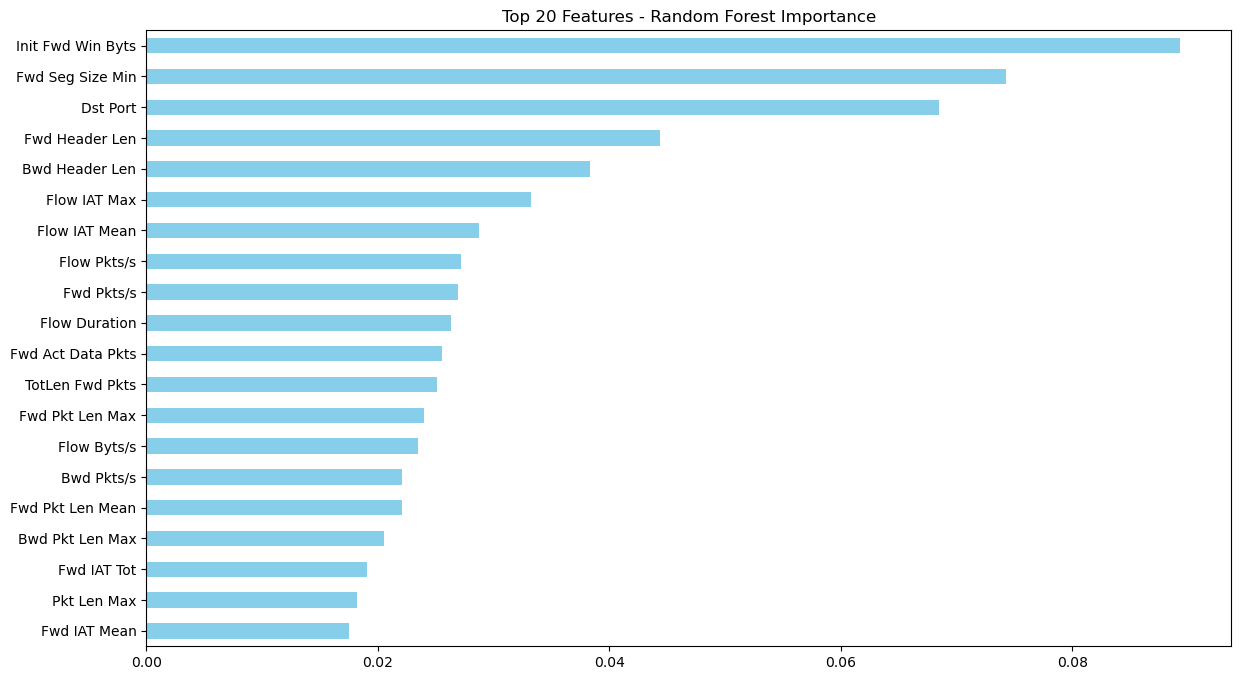

CPU times: total: 1.88 s
Wall time: 1.79 s


In [41]:
%%time
# Extract importance scores using Pandas to get the columns
feature_names = df.drop(columns=['Label']).columns
importances = rf_model.feature_importances_

# Create a sorted Series for plotting
rf_feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the top 20 features
plt.figure(figsize=(14, 8))
rf_feat_importances.head(20).plot(kind='barh', color='skyblue')
plt.title("Top 20 Features - Random Forest Importance")
plt.gca().invert_yaxis()
plt.savefig('RF_20.png', dpi=300)
plt.show()

### 3. XGBoost

In [44]:
%%time

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X, y)

print("XGBoost training complete.")

XGBoost training complete.
CPU times: total: 12min 24s
Wall time: 1min 41s


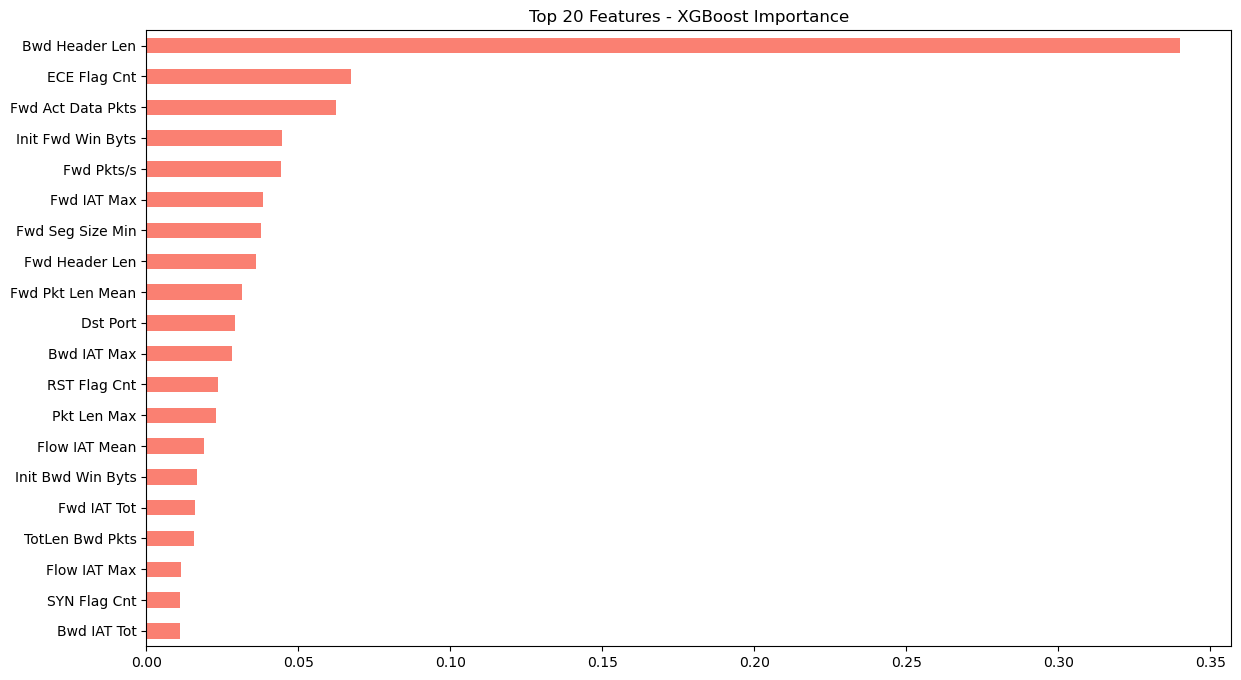

In [46]:
# Extract importance scores
importances_xgb = xgb_model.feature_importances_

# Create a sorted DataFrame
xgb_feat_importances = pd.Series(importances_xgb, index=feature_names).sort_values(ascending=False)

# Plot the top 20 features
plt.figure(figsize=(14, 8))
xgb_feat_importances.head(20).plot(kind='barh', color='salmon')
plt.title("Top 20 Features - XGBoost Importance")
plt.gca().invert_yaxis()
plt.savefig('XGBoost_20.png', dpi=400)
plt.show()

## Save the Top 26 features in a csv file and move to a new notebook to start EDA on them

In [54]:
%%time
# The 26 best features + the Label column
top_26_columns = ['Init Fwd Win Byts', 'Init Bwd Win Byts', 'Flow IAT Std',
       'Fwd Seg Size Min', 'Dst Port', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Act Data Pkts', 'Flow IAT Max', 'Flow IAT Mean', 'Fwd Pkts/s',
       'Flow Pkts/s', 'TotLen Bwd Pkts', 'Pkt Len Max', 'Bwd IAT Mean',
       'RST Flag Cnt', 'ECE Flag Cnt', 'Flow Duration', 'Fwd Pkt Len Max',
       'TotLen Fwd Pkts', 'Active Mean', 'Down/Up Ratio', 'Fwd URG Flags',
       'Protocol', 'Flow Byts/s', 'Label']

df_top26 = df[top_26_columns]

# Save as csv file
df_top26.to_csv('CICIDS2018_top_26.csv', index=False)

print("-" * 50)
print(f"Dataset is saved, and the shape is: {df_top26.shape}")
print("-" * 50)

--------------------------------------------------
✅ Success! Your optimized dataset is saved, and the shape is: (748068, 26)
--------------------------------------------------
CPU times: total: 19.3 s
Wall time: 19.5 s
